In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
from collections import Counter
from imblearn.over_sampling import SMOTE

In [39]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, RepeatedStratifiedKFold

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [41]:
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, classification_report, accuracy_score

In [42]:
import pickle
import os

# Dataset Loading:

In [43]:
df= pd.read_csv('../Data/data.csv')

In [44]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [45]:
pd.set_option('display.max_columns', None)

# Data Preprocessing:

1. `TotalCharges` has `string` data-type. We need to convert it to `int` data-type.

In [46]:
df['TotalCharges']= pd.to_numeric(df['TotalCharges'], errors= 'coerce')

2. `customerID` column has no real meaning for the analysis. So we delete it.

In [47]:
df.drop(columns=['customerID'], inplace=True)

In [48]:
df1= df.copy(deep= True)

In [49]:
text_cols= []
for col in list(df.columns):
    if col not in list(df.describe()):
        text_cols.append(col)

print(text_cols)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [50]:
label= LabelEncoder()

print("Label Encoder Transformation:")

for col in text_cols:
    df1[col]= label.fit_transform(df1[col])
    print(f'{col} : ', df1[col].unique(), '=', label.inverse_transform(df1[col].unique()))

Label Encoder Transformation:
gender :  [0 1] = ['Female' 'Male']
Partner :  [1 0] = ['Yes' 'No']
Dependents :  [0 1] = ['No' 'Yes']
PhoneService :  [0 1] = ['No' 'Yes']
MultipleLines :  [1 0 2] = ['No phone service' 'No' 'Yes']
InternetService :  [0 1 2] = ['DSL' 'Fiber optic' 'No']
OnlineSecurity :  [0 2 1] = ['No' 'Yes' 'No internet service']
OnlineBackup :  [2 0 1] = ['Yes' 'No' 'No internet service']
DeviceProtection :  [0 2 1] = ['No' 'Yes' 'No internet service']
TechSupport :  [0 2 1] = ['No' 'Yes' 'No internet service']
StreamingTV :  [0 2 1] = ['No' 'Yes' 'No internet service']
StreamingMovies :  [0 2 1] = ['No' 'Yes' 'No internet service']
Contract :  [0 1 2] = ['Month-to-month' 'One year' 'Two year']
PaperlessBilling :  [1 0] = ['Yes' 'No']
PaymentMethod :  [2 3 0 1] = ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn :  [0 1] = ['No' 'Yes']


# Addressing Data Imbalance with SMOTE:

In managing imbalanced datasets, two fundamental strategies come into consideration: `Downsampling` and `Upsampling`. We are using `Upsampling` here. 

In [51]:
cols= list(df1.columns)
cols.remove('Churn')

In [52]:
X= df1.loc[:, cols]
y= df1.loc[:, 'Churn']

In [53]:
imputer= SimpleImputer(strategy= 'mean')
X= imputer.fit_transform(X)

over_sample= SMOTE(sampling_strategy= 1)

x1, y1= over_sample.fit_resample(X, y)

In [54]:
print("Class distribution before SMOTE:", Counter(y))
print("Class distribution after SMOTE:", Counter(y1))

Class distribution before SMOTE: Counter({0: 5174, 1: 1869})
Class distribution after SMOTE: Counter({0: 5174, 1: 5174})


In [56]:
X_train, X_test, y_train, y_test = train_test_split(x1, y1, test_size = 0.20, random_state = 2)

In [57]:
X_train_df= pd.DataFrame(X_train, columns= cols)
y_train_df= pd.DataFrame({'Churn': y_train})
X_train_test= pd.concat([X_train_df, y_train_df], axis= 1)

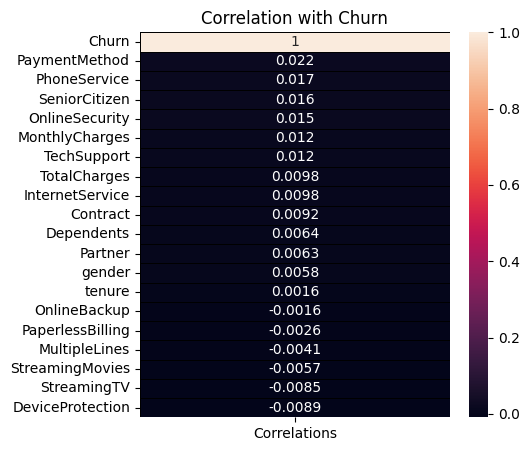

In [58]:
corr = X_train_test.corr()['Churn'].sort_values(ascending=False).to_frame()
corr.columns = ['Correlations']

plt.subplots(figsize=(5, 5))
sns.heatmap(corr, annot=True, linewidths=0.4, linecolor='black')
plt.title('Correlation with Churn')
plt.show()

Following a thorough analysis, it is observed that the categorical features `PhoneService`, `gender`, `StreamingTV`, `StreamingMovies`, `MultipleLines` and `InternetService` demonstrate a notably low association with the target variable `Churn`.

Considering this, a judicious decision has been made to exclude these features from the modeling process. This feature elimination aims to enhance model efficiency and accuracy by focusing on the categorical variables that exhibit a more substantial relation to the prediction of churn.

In [59]:
X_train= X_train_df.drop(columns = ['PhoneService', 'gender','StreamingTV','StreamingMovies','MultipleLines','InternetService'])

X_test_df = pd.DataFrame(X_test, columns=cols)
X_test= X_test_df.drop(columns = ['PhoneService', 'gender','StreamingTV','StreamingMovies','MultipleLines','InternetService'])

In [60]:
scale_cols= ['tenure', 'MonthlyCharges', 'TotalCharges']

In [61]:
min_max= MinMaxScaler()  

X_train[scale_cols] = min_max.fit_transform(X_train[scale_cols])
X_test[scale_cols] = min_max.transform(X_test[scale_cols])

# Model Training and Evaluation:

In [62]:
def model(classifier, X_train, y_train, X_test, y_test):

    classifier.fit(X_train, y_train)
    y_pred= classifier.predict(X_test)

    accuracy= accuracy_score(y_test, y_pred)
    print("Accuracy is: ",accuracy)

    cv= RepeatedStratifiedKFold(
        n_splits= 10, n_repeats= 3, random_state= 1
    )

    print("Cross Validation Score: ", '{0:.2%}'.format(cross_val_score(
        classifier, X_train, y_train, cv= cv, scoring= 'roc_auc'
    ).mean()))

    print("ROC AUC Score: ", '{0:.2%}'.format(roc_auc_score(y_test, y_pred)))

In [63]:
def model_evaluation(classifier, X_test, y_test):

    plt.figure(figsize= (4,4))
    confusion_mat= confusion_matrix(y_test, classifier.predict(X_test))
    names= ['True Neg', 'False Pos', 'False Neg', 'True Pos']
    counts= [value for value in confusion_mat.flatten()]
    percentages= ['{0:.2%}'.format(value) for value in confusion_mat.flatten()/np.sum(confusion_mat)]
    labels= [f'{v1}\n{v2}\n{v3}' for v1, v2, v3 in zip(names,counts,percentages)]
    labels= np.asarray(labels).reshape(2,2)
    sns.heatmap(confusion_mat,annot = labels,cmap = 'Blues',fmt ='')

    print(classification_report(y_test, classifier.predict(X_test)))


## Logistic Regression:

Accuracy is:  0.7705314009661836
Cross Validation Score:  84.98%
ROC AUC Score:  77.07%


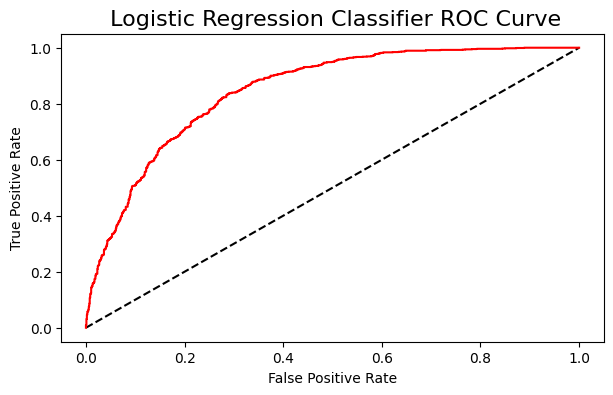

              precision    recall  f1-score   support

           0       0.80      0.73      0.76      1040
           1       0.75      0.81      0.78      1030

    accuracy                           0.77      2070
   macro avg       0.77      0.77      0.77      2070
weighted avg       0.77      0.77      0.77      2070



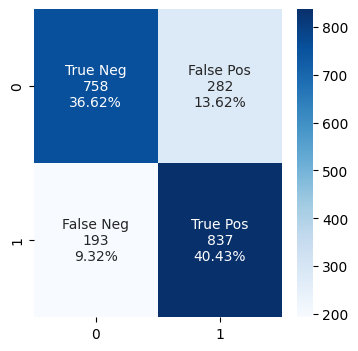

In [64]:
logistic_reg= LogisticRegression()

model(
    classifier= logistic_reg, 
    X_train= X_train,
    y_train= y_train, 
    X_test= X_test,
    y_test= y_test
)

y_pred_prob= logistic_reg.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(7, 4))

plt.plot([0, 1], [0, 1], 'k--' )
plt.plot(fpr, tpr, label='Logistic Regression Classifier',color = "r")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(' Logistic Regression Classifier ROC Curve',fontsize=16)
plt.show()

model_evaluation(
    classifier= logistic_reg,
    X_test= X_test,
    y_test= y_test
)

## K Nearest Neighbours:

Accuracy is:  0.8028985507246377
Cross Validation Score:  87.85%
ROC AUC Score:  80.29%


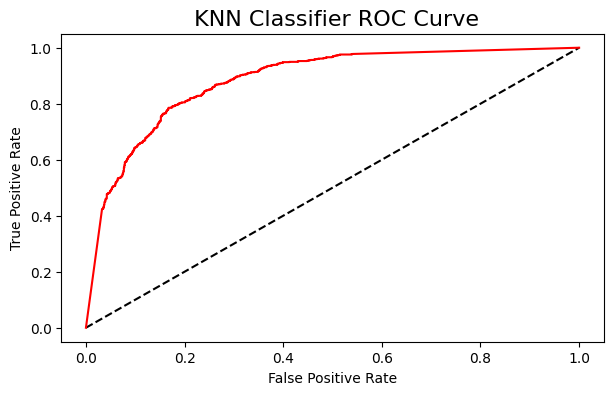

              precision    recall  f1-score   support

           0       0.81      0.79      0.80      1040
           1       0.80      0.81      0.80      1030

    accuracy                           0.80      2070
   macro avg       0.80      0.80      0.80      2070
weighted avg       0.80      0.80      0.80      2070



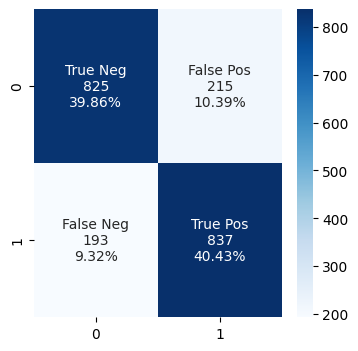

In [65]:
knn= KNeighborsClassifier(
    n_neighbors= 5,
    weights= 'distance'
)

model(
    classifier= knn, 
    X_train= X_train,
    y_train= y_train, 
    X_test= X_test,
    y_test= y_test
)

y_pred_prob= knn.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(7, 4))

plt.plot([0, 1], [0, 1], 'k--' )
plt.plot(fpr, tpr, label='KNN Classifier',color = "r")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(' KNN Classifier ROC Curve',fontsize=16)
plt.show()

model_evaluation(
    classifier= knn,
    X_test= X_test,
    y_test= y_test
)

In [66]:
param_grid= {
    'n_neighbors': [5,7,9,11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

random_search= RandomizedSearchCV(
    estimator= KNeighborsClassifier(),
    param_distributions= param_grid,
    n_iter= 30,
    scoring= 'roc_auc',
    cv= 5,
    n_jobs= -1,
    random_state= 42
)

random_search.fit(X_train, y_train)

best_knn = random_search.best_estimator_

print("Best Parameters:", random_search.best_params_)
print("Best ROC-AUC:", random_search.best_score_)

d:\Projects\Telecom-Churn-Prediction\env\lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 16 is smaller than n_iter=30. Running 16 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Parameters: {'weights': 'distance', 'n_neighbors': 11, 'metric': 'manhattan'}
Best ROC-AUC: 0.8857849958862178


Accuracy is:  0.81256038647343
Cross Validation Score:  89.18%
ROC AUC Score:  81.25%


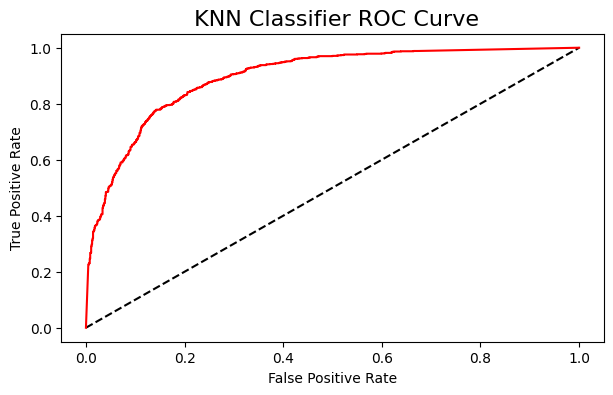

              precision    recall  f1-score   support

           0       0.80      0.83      0.82      1040
           1       0.82      0.80      0.81      1030

    accuracy                           0.81      2070
   macro avg       0.81      0.81      0.81      2070
weighted avg       0.81      0.81      0.81      2070



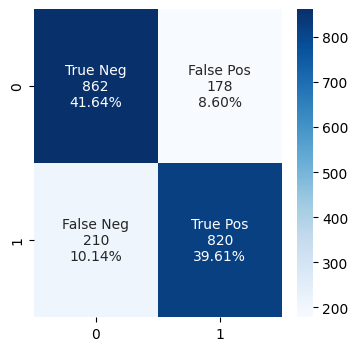

In [67]:
model(
    classifier= best_knn, 
    X_train= X_train,
    y_train= y_train, 
    X_test= X_test,
    y_test= y_test
)

y_pred_prob= best_knn.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(7, 4))

plt.plot([0, 1], [0, 1], 'k--' )
plt.plot(fpr, tpr, label='KNN Classifier',color = "r")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(' KNN Classifier ROC Curve',fontsize=16)
plt.show()

model_evaluation(
    classifier= best_knn,
    X_test= X_test,
    y_test= y_test
)

## Decision Tree Classifier:

Accuracy is:  0.7966183574879228
Cross Validation Score:  85.78%
ROC AUC Score:  79.66%


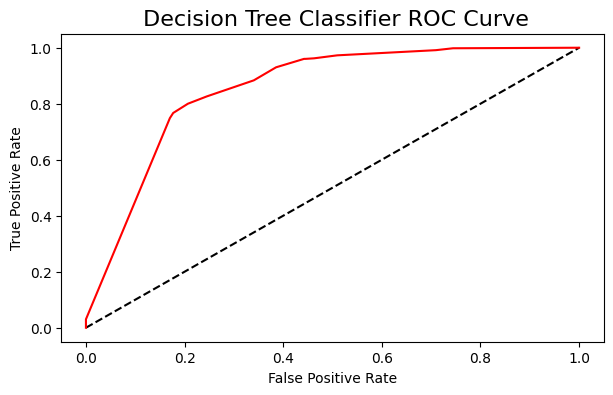

              precision    recall  f1-score   support

           0       0.80      0.79      0.80      1040
           1       0.79      0.80      0.80      1030

    accuracy                           0.80      2070
   macro avg       0.80      0.80      0.80      2070
weighted avg       0.80      0.80      0.80      2070



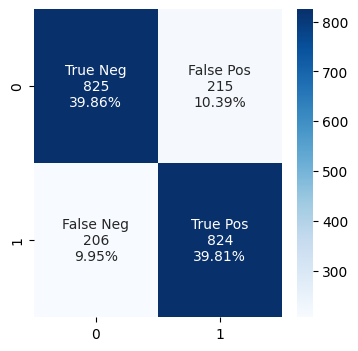

In [68]:
decision_tree= DecisionTreeClassifier(
    random_state= 10, 
    max_depth= 4,
    min_samples_leaf= 1
)

model(
    classifier= decision_tree, 
    X_train= X_train,
    y_train= y_train, 
    X_test= X_test,
    y_test= y_test
)


y_pred_prob= decision_tree.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(7, 4))

plt.plot([0, 1], [0, 1], 'k--' )
plt.plot(fpr, tpr, label='Decision Tree Classifier',color = "r")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(' Decision Tree Classifier ROC Curve',fontsize=16)
plt.show()

model_evaluation(
    classifier= decision_tree,
    X_test= X_test,
    y_test= y_test
)

In [69]:
param_grid= {
    'max_depth': [None, 5, 10, 15, 20, 30],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

random_search= RandomizedSearchCV(
    estimator= DecisionTreeClassifier(),
    param_distributions= param_grid,
    n_iter= 30,
    scoring= 'roc_auc',
    cv= 5,
    n_jobs= -1,
    random_state= 42
)

random_search.fit(X_train, y_train)

best_decision_tree = random_search.best_estimator_

print("Best Parameters:", random_search.best_params_)
print("Best ROC-AUC:", random_search.best_score_)

Best Parameters: {'min_samples_split': 20, 'min_samples_leaf': 10, 'max_depth': 10, 'criterion': 'entropy'}
Best ROC-AUC: 0.8987286112749497


Accuracy is:  0.8241545893719807
Cross Validation Score:  89.98%
ROC AUC Score:  82.44%


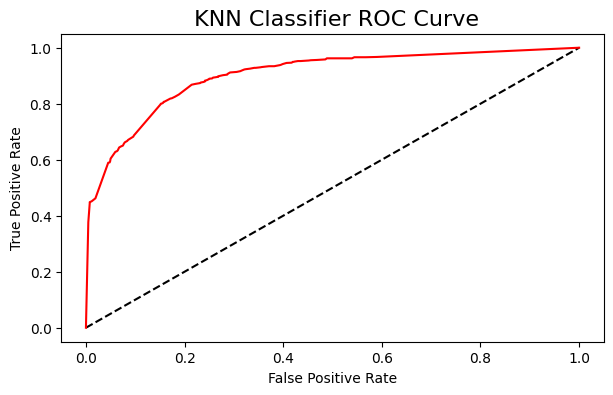

              precision    recall  f1-score   support

           0       0.86      0.78      0.82      1040
           1       0.80      0.87      0.83      1030

    accuracy                           0.82      2070
   macro avg       0.83      0.82      0.82      2070
weighted avg       0.83      0.82      0.82      2070



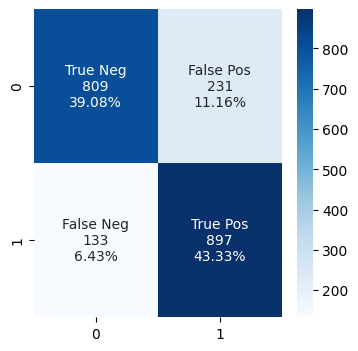

In [70]:
model(
    classifier= best_decision_tree, 
    X_train= X_train,
    y_train= y_train, 
    X_test= X_test,
    y_test= y_test
)

y_pred_prob= best_decision_tree.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(7, 4))

plt.plot([0, 1], [0, 1], 'k--' )
plt.plot(fpr, tpr, label='KNN Classifier',color = "r")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(' KNN Classifier ROC Curve',fontsize=16)
plt.show()

model_evaluation(
    classifier= best_decision_tree,
    X_test= X_test,
    y_test= y_test
)

## Random Forest Classifier:

Accuracy is:  0.8082125603864734
Cross Validation Score:  89.85%
ROC AUC Score:  80.85%


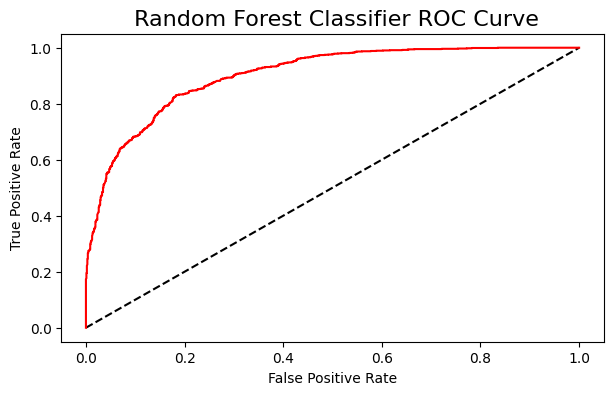

              precision    recall  f1-score   support

           0       0.85      0.75      0.80      1040
           1       0.77      0.87      0.82      1030

    accuracy                           0.81      2070
   macro avg       0.81      0.81      0.81      2070
weighted avg       0.81      0.81      0.81      2070



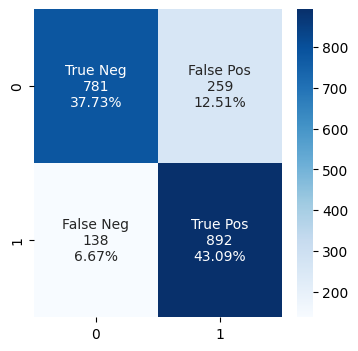

In [71]:
random_forest= RandomForestClassifier(
    max_depth= 4,
    random_state= 0
)

model(
    classifier= random_forest, 
    X_train= X_train,
    y_train= y_train, 
    X_test= X_test,
    y_test= y_test
)

y_pred_prob= random_forest.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(7, 4))

plt.plot([0, 1], [0, 1], 'k--' )
plt.plot(fpr, tpr, label='Random Forest Classifier',color = "r")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(' Random Forest Classifier ROC Curve',fontsize=16)
plt.show()

model_evaluation(
    classifier= random_forest,
    X_test= X_test,
    y_test= y_test
)

In [72]:
param_grid= {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

random_search= RandomizedSearchCV(
    estimator= RandomForestClassifier(),
    param_distributions= param_grid,
    n_iter= 30,
    scoring= 'roc_auc',
    cv= 5,
    n_jobs= -1,
    random_state= 42
)

random_search.fit(X_train, y_train)

best_random_forest = random_search.best_estimator_

print("Best Parameters:", random_search.best_params_)
print("Best ROC-AUC:", random_search.best_score_)

Best Parameters: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': None, 'bootstrap': False}
Best ROC-AUC: 0.9350443381904465


Accuracy is:  0.8603864734299517
Cross Validation Score:  93.65%
ROC AUC Score:  86.03%


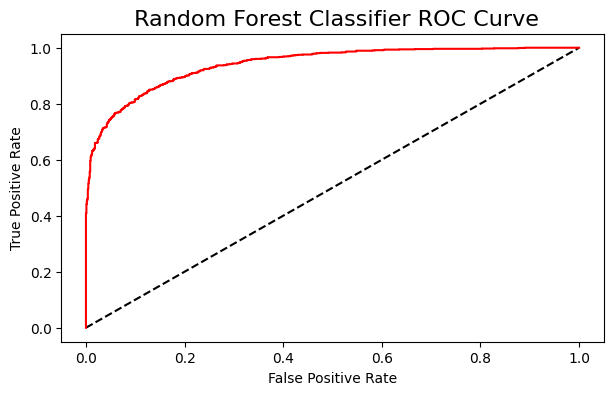

              precision    recall  f1-score   support

           0       0.85      0.87      0.86      1040
           1       0.87      0.85      0.86      1030

    accuracy                           0.86      2070
   macro avg       0.86      0.86      0.86      2070
weighted avg       0.86      0.86      0.86      2070



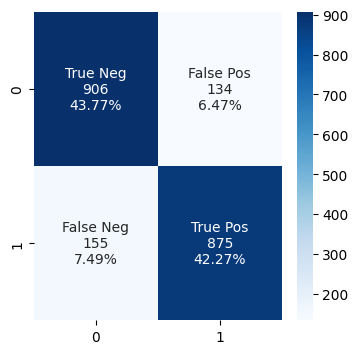

In [73]:
model(
    classifier= best_random_forest, 
    X_train= X_train,
    y_train= y_train, 
    X_test= X_test,
    y_test= y_test
)

y_pred_prob= best_random_forest.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(7, 4))

plt.plot([0, 1], [0, 1], 'k--' )
plt.plot(fpr, tpr, label='Random Forest Classifier',color = "r")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(' Random Forest Classifier ROC Curve',fontsize=16)
plt.show()

model_evaluation(
    classifier= best_random_forest,
    X_test= X_test,
    y_test= y_test
)

## XG Boost:

Accuracy is:  0.8584541062801933
Cross Validation Score:  93.81%
ROC AUC Score:  85.85%


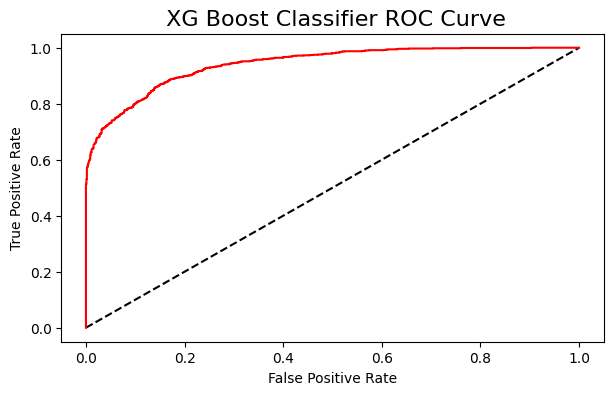

              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1040
           1       0.86      0.86      0.86      1030

    accuracy                           0.86      2070
   macro avg       0.86      0.86      0.86      2070
weighted avg       0.86      0.86      0.86      2070



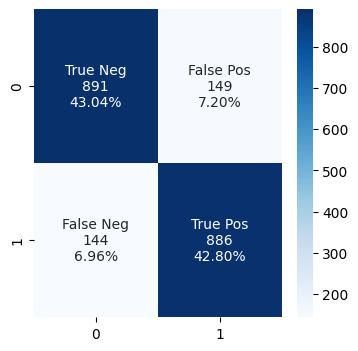

In [74]:
xgb_classifier= XGBClassifier(
    learning_rate= 0.01,
    max_depth= 3,
    n_estimators= 1000
)

model(
    classifier= xgb_classifier, 
    X_train= X_train,
    y_train= y_train, 
    X_test= X_test,
    y_test= y_test
)


y_pred_prob= xgb_classifier.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(7, 4))

plt.plot([0, 1], [0, 1], 'k--' )
plt.plot(fpr, tpr, label='XG Boost Classifier',color = "r")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(' XG Boost Classifier ROC Curve',fontsize=16)
plt.show()

model_evaluation(
    classifier= xgb_classifier,
    X_test= X_test,
    y_test= y_test
)

In [76]:
param_grid= {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 10],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5],
    'reg_lambda': [0.1, 1, 5, 10]
}

random_search= RandomizedSearchCV(
    estimator= XGBClassifier(),
    param_distributions= param_grid,
    n_iter= 30,
    scoring= 'roc_auc',
    cv= 5,
    n_jobs= -1,
    random_state= 42
)

random_search.fit(X_train, y_train)

best_xgboost = random_search.best_estimator_

print("Best Parameters:", random_search.best_params_)
print("Best ROC-AUC:", random_search.best_score_)

Best Parameters: {'subsample': 1.0, 'reg_lambda': 0.1, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 0.6}
Best ROC-AUC: 0.9396272942028034


Accuracy is:  0.8594202898550725
Cross Validation Score:  94.08%
ROC AUC Score:  85.94%


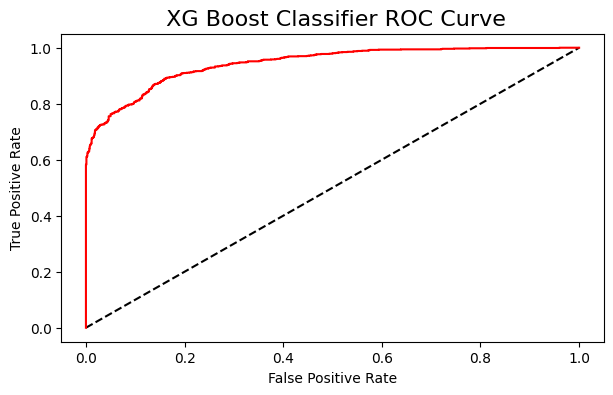

              precision    recall  f1-score   support

           0       0.85      0.87      0.86      1040
           1       0.87      0.85      0.86      1030

    accuracy                           0.86      2070
   macro avg       0.86      0.86      0.86      2070
weighted avg       0.86      0.86      0.86      2070



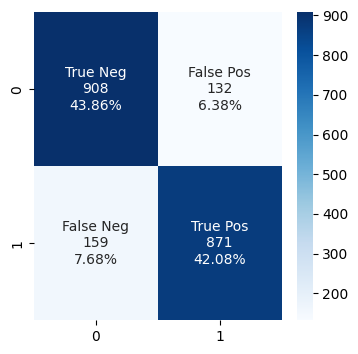

In [77]:
model(
    classifier= best_xgboost, 
    X_train= X_train,
    y_train= y_train, 
    X_test= X_test,
    y_test= y_test
)

y_pred_prob= best_xgboost.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(7, 4))

plt.plot([0, 1], [0, 1], 'k--' )
plt.plot(fpr, tpr, label='XG Boost Classifier',color = "r")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(' XG Boost Classifier ROC Curve',fontsize=16)
plt.show()

model_evaluation(
    classifier= best_xgboost,
    X_test= X_test,
    y_test= y_test
)

In [78]:
best_xgboost.feature_names_in_

array(['SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'], dtype='<U16')

# Model Export:

In [80]:
os.makedirs('../Model', exist_ok=True)

In [81]:
model_dir = os.path.join('..', 'Model')

model_path = os.path.join(model_dir, 'model.pkl')

with open(model_path, 'wb') as f:
    pickle.dump(best_xgboost, f)

In [82]:
scaler_path = os.path.join(model_dir, 'scaler.pkl')

with open(scaler_path, 'wb') as f:
    pickle.dump(min_max, f)

In [85]:
model = pickle.load(open('../Model/model.pkl', 'rb'))
scaler = pickle.load(open('../Model/scaler.pkl', 'rb'))

model.predict(X_test[10:21])

array([1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1])

In [88]:
list(y_test[10:21])

[1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1]